# Calibrate Readout Histogram: load saved arrays → plot

This notebook is for analyzing data from **04b_calibrate_readout_histogram.py**:

- Load the saved `data.json` + `arrays.npz` (DataHandler format)
- Plot the time-resolved photon count histograms for signal (no MW) and dark (with MW) measurements
- Visualize the readout window timing
- Data is saved at time_bin resolution (0.5 or 1.0 ns) instead of aggregated bins


## 1) Imports + locate NV2_array


In [1]:
from __future__ import annotations
import sys
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
from importlib import reload
import nv2_analysis.fits as fits

def find_workspace_root(start: Path) -> Path:
    start = start.resolve()
    for p in [start, *start.parents]:
        if (p / "qua-libs").exists():
            return p

WORKSPACE = find_workspace_root(Path.cwd())

ANALYSIS = (WORKSPACE / "qua-libs/Quantum-Control-Applications/Optically addressable spin qubits/NV2_array/analysis").resolve()

NV2 = ANALYSIS.parent

DATA_ROOT = NV2 / "Data"

sys.path.insert(0, str(ANALYSIS))

from nv2_analysis.dataset import DatasetReader  # noqa: E402
from nv2_analysis.fits import ExperimentFitter  # noqa: E402

plt.rcParams["figure.figsize"] = (6.4, 4.8)

CC_NS = 4.0 # 4 ns per clock cycle

2026-02-13 13:45:36,947 - qm - INFO     - Starting session: c93db6e9-4513-4594-84fa-724b1b192443


## 2) Load saved arrays


In [21]:
reader = DatasetReader(nv_root=NV2, data_root=DATA_ROOT)

# For 04b_calibrate_readout_histogram.py data
EXPERIMENT_TAG = "calibrate_readout_histogram"

# USER INPUT: Optional histogram binning/smoothing (set to 1 for no binning)
bin_factor = 1  # Bin this many time_bin samples together (e.g., 24 for 12ns bins with 0.5ns time_bin)

# Choose a specific dataset folder or leave None for "latest":
#   DATASET = None
#   DATASET = r"2026-02-13\#187_calibrate_readout_histogram_120000"  # relative to Data/
#   DATASET = r"C:\\...\\NV2_array\\Data\\2026-02-13\\#187_calibrate_readout_histogram_120000"  # absolute

DATASET = None
#DATASET = r"2026-02-12\#181_calibrate_readout_154933"  # relative to Data/ --- IGNORE ---

def find_latest_by_tag(tag: str) -> Path:
    candidates = [p.parent for p in DATA_ROOT.rglob("data.json") if p.is_file() and tag in p.parent.name]
    if not candidates:
        raise FileNotFoundError(f"No datasets matching tag {tag!r} under {DATA_ROOT}")
    candidates.sort(key=lambda p: p.stat().st_mtime, reverse=True)
    return candidates[0]

ds_folder = find_latest_by_tag(EXPERIMENT_TAG) if DATASET is None else reader.resolve_dataset(DATASET).folder
ds = reader.resolve_dataset(ds_folder)

data = reader.load(ds)

# Load histogram data (from 04b script: counts_vec, counts_dark_vec)
t_vec = np.asarray(data["t_vec"], dtype=float)  # time bins in ns
counts_vec = np.asarray(data["counts_vec"], dtype=float)  # histogram (no MW - bright state)
counts_dark_vec = np.asarray(data["counts_dark_vec"], dtype=float)  # histogram (with MW - dark state)

n_avg = int(data.get("n_avg", 1))
# For 04b: iteration not saved, use n_avg as approximation
iteration = int(data.get("iteration", n_avg))

# Get time bin resolution from QOP version
version_str = data.get("qop_version", "3.5.0")
version_tuple = tuple(map(int, version_str.split("."))) if isinstance(version_str, str) else (3, 5, 0)
time_bin = 0.5 if version_tuple >= (3, 5, 0) else 1.0

# Apply binning if requested
if bin_factor > 1:
    # Reshape and sum to create larger bins
    n_bins = len(counts_vec) // bin_factor
    counts_vec = counts_vec[:n_bins * bin_factor].reshape(n_bins, bin_factor).sum(axis=1)
    counts_dark_vec = counts_dark_vec[:n_bins * bin_factor].reshape(n_bins, bin_factor).sum(axis=1)
    t_vec = t_vec[:n_bins * bin_factor:bin_factor]
    effective_bin_width = time_bin * bin_factor
else:
    effective_bin_width = time_bin

# Calculate bin centers for plotting
hist_bin_centers = t_vec + effective_bin_width / 2

# Convert to count rates (kcps) - normalize by iteration count and bin width
# NOTE: Factor of 2 correction to match experimental live plotting
signal_kcps = counts_vec / 1000.0 / (effective_bin_width * 1e-9 * 2) / iteration
dark_kcps = counts_dark_vec / 1000.0 / (effective_bin_width * 1e-9 * 2) / iteration

print(f"Loaded: {ds.folder}")
print(f"Time bin: {time_bin} ns")
print(f"Bin factor: {bin_factor}")
print(f"Effective histogram bin width: {effective_bin_width} ns")
print(f"Number of data points: {len(counts_vec)}")
print(f"Number of averages: {n_avg}")


Loaded: C:\Users\SPUD1\Documents\experiment_workspace\qua-libs\Quantum-Control-Applications\Optically addressable spin qubits\NV2_array\Data\2026-02-13\#210_calibrate_readout_histogram_142732
Time bin: 0.5 ns
Bin factor: 1
Effective histogram bin width: 0.5 ns
Number of data points: 4000
Number of averages: 25000000


## 3) Plot time-resolved photon counts

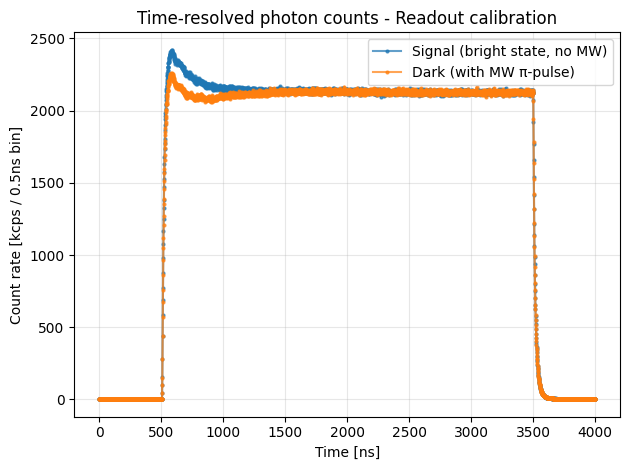

In [22]:
fig, ax = plt.subplots(1, 1)

# Plot both histograms
ax.plot(hist_bin_centers, signal_kcps, "o-", ms=2, label="Signal (bright state, no MW)", alpha=0.7)
ax.plot(hist_bin_centers, dark_kcps, "o-", ms=2, label="Dark (with MW π-pulse)", alpha=0.7)

ax.set_xlabel("Time [ns]")
ax.set_ylabel(f"Count rate [kcps / {effective_bin_width:.1f}ns bin]")
ax.set_title("Time-resolved photon counts - Readout calibration")
ax.grid(True, alpha=0.3)
ax.legend()

plt.tight_layout()
plt.show()


Optimal diff_sig threshold c_i_opt: 59.2310 kcps
Ratio at optimum: 2.000

Optimal readout window:
  Start time: 522 ns
  Stop time: 1139 ns
  Duration: 618 ns

SNR in optimal window: 39.47


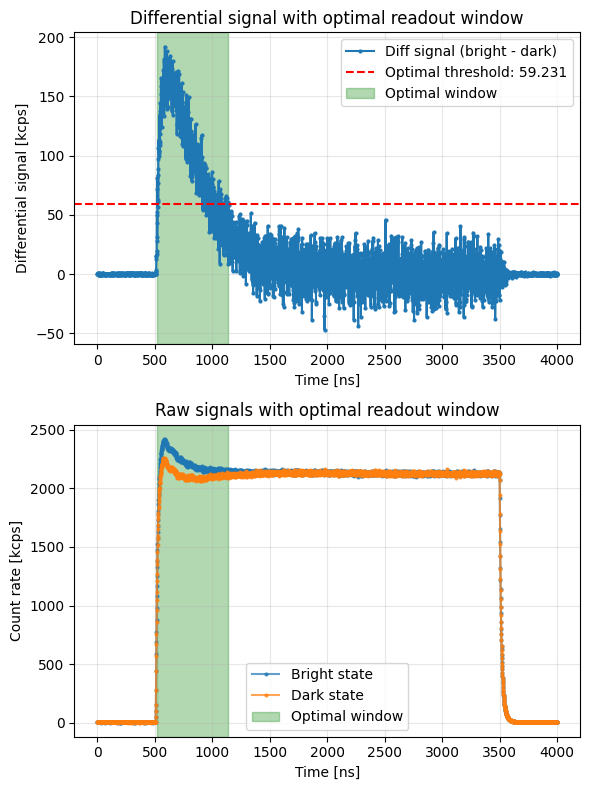

In [23]:
# Optimize readout window using Garrett method (find average threshold)
# Calculate differential signal (bright - dark)
# 1. iterate over the range of the diff signal values, for each value c_i, 
#    calculate the average of the diff signal (bright - dark) which is greater than c_i -> c_ave_i.
# 2. solve for the optimal threshold (i_opt) where c_ave_i/c_i = 2 -> c_i_opt
# 3. the optimal readout window is set to be from t_start and t_stop s.t. diff_sig > c_i_opt

diff_sig = signal_kcps - dark_kcps

# Step 1: Iterate over diff_sig threshold values
c_min = 0
c_max = np.max(diff_sig) * 0.95  # Use 95% of max diff_sig
c_step = 0.001
c_thresholds = np.arange(c_min, c_max, c_step)

c_ave_values = []

for c_i in c_thresholds:
    # Find points where diff_sig > c_i
    mask = diff_sig > c_i
    if np.sum(mask) > 0:
        # Calculate average diff_sig for those points
        c_ave_i = np.mean(diff_sig[mask])
        c_ave_values.append(c_ave_i)
    else:
        c_ave_values.append(np.nan)

c_ave_values = np.array(c_ave_values)

# Step 2: Find index where c_ave_i / c_i ≈ 2
ratios = c_ave_values / c_thresholds
valid_mask = ~np.isnan(ratios) & (c_thresholds > 0)
valid_ratios = ratios[valid_mask]
valid_c_thresholds = c_thresholds[valid_mask]

# Find the index closest to ratio = 2
target_ratio = 2.0
idx_opt = np.argmin(np.abs(valid_ratios - target_ratio))
c_i_opt = valid_c_thresholds[idx_opt]
ratio_opt = valid_ratios[idx_opt]

print(f"Optimal diff_sig threshold c_i_opt: {c_i_opt:.4f} kcps")
print(f"Ratio at optimum: {ratio_opt:.3f}")

# Step 3: Find readout window where diff_sig ≥ c_i_opt
optimal_window_mask = diff_sig >= c_i_opt
optimal_indices = np.where(optimal_window_mask)[0]

if len(optimal_indices) > 0:
    t_start_idx = optimal_indices[0]
    t_stop_idx = optimal_indices[-1]
    
    t_start = hist_bin_centers[t_start_idx]
    t_stop = hist_bin_centers[t_stop_idx]
    optimal_window_duration = t_stop - t_start + effective_bin_width
    
    print(f"\nOptimal readout window:")
    print(f"  Start time: {t_start:.0f} ns")
    print(f"  Stop time: {t_stop:.0f} ns")
    print(f"  Duration: {optimal_window_duration:.0f} ns")
    
    # Plot the results
    fig, axes = plt.subplots(2, 1, figsize=(6, 8))
    
    # Plot 1: Differential signal with optimal window highlighted
    ax = axes[0]
    ax.plot(hist_bin_centers, diff_sig, 'o-', ms=2, label='Diff signal (bright - dark)')
    ax.axhline(y=c_i_opt, color='r', linestyle='--', label=f'Optimal threshold: {c_i_opt:.3f}')
    ax.axvspan(t_start, t_stop, alpha=0.3, color='green', label='Optimal window')
    ax.set_xlabel('Time [ns]')
    ax.set_ylabel('Differential signal [kcps]')
    ax.set_title('Differential signal with optimal readout window')
    ax.grid(True, alpha=0.3)
    ax.legend()
    
    # Plot 2: Signal and dark counts with window
    ax = axes[1]
    ax.plot(hist_bin_centers, signal_kcps, 'o-', ms=2, label='Bright state', alpha=0.7)
    ax.plot(hist_bin_centers, dark_kcps, 'o-', ms=2, label='Dark state', alpha=0.7)
    ax.axvspan(t_start, t_stop, alpha=0.3, color='green', label='Optimal window')
    ax.set_xlabel('Time [ns]')
    ax.set_ylabel('Count rate [kcps]')
    ax.set_title('Raw signals with optimal readout window')
    ax.grid(True, alpha=0.3)
    ax.legend()

    # Evaluate SNR within optimal window using Poisson noise approximation
    # Integrate difference signal to get photon count diff
    signal = np.sum(signal_kcps[optimal_indices] - dark_kcps[optimal_indices])
    noise = np.sqrt(np.sum(signal_kcps[optimal_indices] + dark_kcps[optimal_indices]))  # Poisson noise
    snr = signal / noise 
    print(f"\nSNR in optimal window: {snr:.2f}")

    plt.tight_layout()
    plt.show()
    
else:
    print("Warning: Could not find optimal readout window. Check data quality.")


## 4) Calculate optimal readout window for maximum SNR

In [20]:
# 2D optimization of t_start/t_stop by maximizing SNR over all windows
# Using Poisson noise approximation: noise = sqrt(signal + dark)

diff = signal_kcps - dark_kcps
signal_plus_dark = signal_kcps + dark_kcps
n = diff.size

# Cumulative sums for efficient window sum calculation
cs_diff = np.cumsum(diff)
cs_sum = np.cumsum(signal_plus_dark)

best_snr = -np.inf
best_i = 0
best_j = 0

for i in range(n):
    for j in range(i, n):
        # Sum of differential signal in window [i, j]
        signal_sum = cs_diff[j] - (cs_diff[i - 1] if i > 0 else 0.0)
        
        # Sum of (signal + dark) for Poisson noise approximation
        sum_for_noise = cs_sum[j] - (cs_sum[i - 1] if i > 0 else 0.0)
        
        # Poisson noise: sqrt(sum of counts)
        noise = np.sqrt(sum_for_noise) if sum_for_noise > 0 else 1e-10
        
        # SNR
        snr_val = signal_sum / noise
        
        if snr_val > best_snr:
            best_snr = snr_val
            best_i = i
            best_j = j

t_start_opt = hist_bin_centers[best_i]
t_stop_opt = hist_bin_centers[best_j]
opt_duration = t_stop_opt - t_start_opt + effective_bin_width

print("Optimal 2D SNR window (Poisson noise):")
print(f"  Start time: {t_start_opt:.0f} ns")
print(f"  Stop time:  {t_stop_opt:.0f} ns")
print(f"  Duration:   {opt_duration:.0f} ns")
print(f"  Max SNR:    {best_snr:.2f}")
print(f"\nUpdate 'meas_len_1' in configuration to {int(opt_duration)} ns")


Optimal 2D SNR window (Poisson noise):
  Start time: 521 ns
  Stop time:  1052 ns
  Duration:   532 ns
  Max SNR:    37.56

Update 'meas_len_1' in configuration to 531 ns


: 

: 

: 